# Seminar 07: Transfer Learning with Pretrained ResNet18 on CIFAR-10

**Student Version**

Goals for today:
- Inspect the preprocessing expected by an ImageNet-pretrained CNN
- Replace the ImageNet classifier head with a CIFAR-10 head
- Freeze a backbone and fine-tune only selected layers
- Use pretrained features as embeddings
- Compare frozen and fine-tuned transfer-learning runs


## 0. Setup


In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

### Configuration


In [2]:
@dataclass
class Config:
    seed: int = 42
    train_n: object = 12000
    val_n: int = 2000
    batch_size: int = 64
    epochs_frozen: int = 2
    epochs_ft: int = 2
    lr_head: float = 1e-3
    lr_backbone: float = 1e-4


cfg = Config()
cfg


Config(seed=42, train_n=12000, val_n=2000, batch_size=64, epochs_frozen=2, epochs_ft=2, lr_head=0.001, lr_backbone=0.0001)

### Helpers



In [3]:
def count_total_parameters(model):
    return sum(p.numel() for p in model.parameters())


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


_counter_check_model = nn.Sequential(nn.Linear(4, 3), nn.Linear(3, 2))
for param in _counter_check_model[0].parameters():
    param.requires_grad = False

assert count_total_parameters(_counter_check_model) == 4 * 3 + 3 + 3 * 2 + 2
assert count_trainable_parameters(_counter_check_model) == 3 * 2 + 2


In [4]:
CIFAR10_CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def denormalize_imagenet(x):
    return (x.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)


def show_images(images, labels=None, class_names=None, nrow=8, figsize=(12, 4), denormalize=True):
    images = images.detach().cpu()
    if denormalize:
        images = denormalize_imagenet(images)
    n_images = images.shape[0]
    ncol = int(math.ceil(n_images / nrow))
    plt.figure(figsize=figsize)
    for i in range(n_images):
        plt.subplot(ncol, nrow, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis('off')
        if labels is not None:
            label = int(labels[i])
            title = class_names[label] if class_names is not None else str(label)
            plt.title(title, fontsize=8)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def accuracy_multiclass(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


def make_history():
    return {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def plot_history(history, title_prefix=''):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure()
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='train')
    plt.plot(epochs, history['val_acc'], label='val')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()


def trainable_named_parameters(model):
    return [name for name, param in model.named_parameters() if param.requires_grad]


def summarize_result(name, model, history, elapsed_sec):
    return {
        'name': name,
        'total_params': count_total_parameters(model),
        'trainable_params': count_trainable_parameters(model),
        'best_val_acc': float(max(history['val_acc'])),
        'final_train_acc': float(history['train_acc'][-1]),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_gap': float(history['train_acc'][-1] - history['val_acc'][-1]),
        'elapsed_sec': float(elapsed_sec),
    }


## 1. Provided Pretrained Setup and CIFAR-10 Loaders

The pretrained weights and data pipeline are infrastructure today. The important idea is that the transform belongs to the pretrained weights, not to CIFAR-10 itself.


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


xb: torch.Size([64, 3, 224, 224]) torch.float32
yb: torch.Size([64]) torch.int64


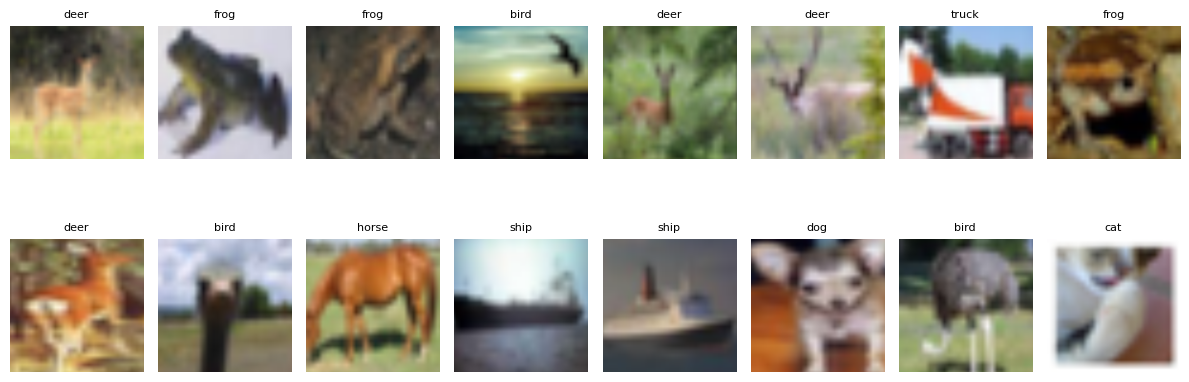

In [5]:
weights = ResNet18_Weights.DEFAULT
pretrained_transform = weights.transforms()
print(pretrained_transform)

raw_preview_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
raw_preview_image, raw_preview_label = raw_preview_ds[0]


def build_cifar10_loaders(transform, cfg):
    train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    generator = torch.Generator().manual_seed(cfg.seed)
    perm = torch.randperm(len(train_full), generator=generator)
    val_idx = perm[:cfg.val_n]
    train_idx = perm[cfg.val_n:]
    if cfg.train_n is not None:
        train_idx = train_idx[:cfg.train_n]

    train_ds = Subset(train_full, train_idx.tolist())
    val_ds = Subset(train_full, val_idx.tolist())
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, train_idx, val_idx


train_loader, val_loader, train_idx, val_idx = build_cifar10_loaders(pretrained_transform, cfg)
xb, yb = next(iter(train_loader))
print('xb:', xb.shape, xb.dtype)
print('yb:', yb.shape, yb.dtype)
show_images(xb[:16], labels=yb[:16], class_names=CIFAR10_CLASS_NAMES, nrow=8, figsize=(12, 5), denormalize=True)

assert xb.ndim == 4 and xb.shape[1:] == (3, 224, 224)
assert yb.ndim == 1 and yb.dtype in (torch.int64, torch.long)


### Provided Training Helpers
Training is used for demos in this seminar, but implementing the loop is no longer the task.


In [6]:
def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits.detach(), yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits, yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


def run_training(name, model, train_loader, val_loader, epochs, lr, opt=None):
    model = model.to(device)
    if opt is None:
        opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = make_history()
    started = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        print(f'{name:14s} epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}')

    elapsed_sec = time.time() - started
    return {'name': name, 'model': model, 'history': history, 'elapsed_sec': elapsed_sec}


## 2. Exercise 1: Inspect and Stress-Test the Pretrained Transform

Apply the official ResNet18 transform to one raw CIFAR-10 image and compare it with a deliberately wrong/simple transform.

Use:
- `raw_preview_image`: a PIL image from CIFAR-10
- `pretrained_transform`: `weights.transforms()` from `ResNet18_Weights.DEFAULT`
- `transforms.ToTensor()` as the wrong/simple baseline

Fill:
- official transform metadata: `official_resize_size`, `official_crop_size`, `official_mean`, `official_std`
- raw image size
- official transformed tensor shape/range
- wrong transformed tensor shape/range
- `official_is_plain_zero_one_tensor`: should be `False` after ImageNet normalization
- `wrong_is_plain_zero_one_tensor`: should be `True`

This exercise combines two ideas: pretrained models need their specific transform, and you should inspect the transform object rather than guessing preprocessing.


In [ ]:
# Exercise 1

wrong_transform = transforms.ToTensor()

official_resize_size = None
official_crop_size = None
official_mean = None
official_std = None

raw_size = None
transformed_image = None
wrong_image = None

transformed_shape = None
wrong_shape = None
transformed_min = None
transformed_max = None
wrong_min = None
wrong_max = None

official_is_plain_zero_one_tensor = None
wrong_is_plain_zero_one_tensor = None

print('official resize/crop:', official_resize_size, official_crop_size)
print('official mean/std:', official_mean, official_std)
print('raw PIL size:', raw_size)
print('official transformed shape:', transformed_shape)
print('wrong transformed shape   :', wrong_shape)
print('official min/max:', transformed_min, transformed_max)
print('wrong min/max   :', wrong_min, wrong_max)
print('official plain [0, 1] tensor:', official_is_plain_zero_one_tensor)
print('wrong plain [0, 1] tensor   :', wrong_is_plain_zero_one_tensor)

assert raw_size == (32, 32)
assert transformed_shape == (3, 224, 224)
assert wrong_shape == (3, 32, 32)
assert official_resize_size is not None
assert official_crop_size is not None
assert len(official_mean) == 3 and len(official_std) == 3
assert isinstance(transformed_min, float) and isinstance(transformed_max, float)
assert isinstance(wrong_min, float) and isinstance(wrong_max, float)
assert official_is_plain_zero_one_tensor is False
assert wrong_is_plain_zero_one_tensor is True


## 3. Exercise 2: Replace the Head and Freeze the Backbone

Build a frozen feature extractor:
1. Load pretrained ResNet18.
2. Replace the ImageNet `fc` layer with a CIFAR-10 `Linear` layer.
3. Freeze all parameters.
4. Unfreeze only the new `fc` layer.

Useful contracts:
```python
model = resnet18(weights=weights)
model.fc.in_features #  number of produced features before head
model.parameters() #  list of model's parameters
param.requires_grad = False #  turns off updating parameter's weights
```

Fill:
- `frozen_model`
- `frozen_trainable_names`
- `frozen_trainable_params`
- `frozen_total_params`


In [ ]:
# Exercise 2

frozen_model = None


frozen_trainable_names = trainable_named_parameters(frozen_model)
frozen_trainable_params = count_trainable_parameters(frozen_model)
frozen_total_params = count_total_parameters(frozen_model)

with torch.no_grad():
    frozen_logits = frozen_model(xb[:4].to(device))

print('logits:', frozen_logits.shape)
print('trainable params:', frozen_trainable_params)
print('trainable names:', frozen_trainable_names[:5])

assert frozen_logits.shape == (4, 10)
assert frozen_trainable_names == ['fc.weight', 'fc.bias']
assert frozen_trainable_params == 512 * 10 + 10
assert frozen_total_params > frozen_trainable_params
assert all(not p.requires_grad for name, p in frozen_model.named_parameters() if not name.startswith('fc.'))
assert all(p.requires_grad for name, p in frozen_model.named_parameters() if name.startswith('fc.'))


## 4. Train the Frozen Head

Only the new classifier head is trained. The pretrained backbone acts as a fixed feature extractor.


In [ ]:
frozen_result = run_training('frozen', frozen_model, train_loader, val_loader, cfg.epochs_frozen, cfg.lr_head)
plot_history(frozen_result['history'], title_prefix='Frozen ResNet18: ')
frozen_summary = summarize_result('frozen', frozen_result['model'], frozen_result['history'], frozen_result['elapsed_sec'])
frozen_summary


## 5. Exercise 3: Choose a Fine-Tuning Policy and Learning Rates

Build a second ResNet18 for partial fine-tuning.

Policy:
- replace `fc` for 10 CIFAR-10 classes
- freeze everything first
- unfreeze only `layer4` and `fc`
- create optimizer parameter groups so the new head can learn faster than the pretrained backbone block

Learning-rate policy:
- `layer4`: `cfg.lr_backbone`
- `fc`: `cfg.lr_head`

Fill:
- `ft_model`
- `ft_trainable_names`
- `ft_trainable_params`
- `ft_total_params`
- `layer_status`
- `ft_param_groups`
- `ft_group_lrs`
- `ft_group_param_counts`

Useful contract:
```python
torch.optim.Adam([
    {'params': some_parameters, 'lr': ...},
    {'params': other_parameters, 'lr': ...},
])
```


In [ ]:
# Exercise 3

ft_model = None

ft_trainable_names = trainable_named_parameters(ft_model)
ft_trainable_params = count_trainable_parameters(ft_model)
ft_total_params = count_total_parameters(ft_model)
layer_status = {
    'layer1': any(p.requires_grad for p in ft_model.layer1.parameters()),
    'layer2': any(p.requires_grad for p in ft_model.layer2.parameters()),
    'layer3': any(p.requires_grad for p in ft_model.layer3.parameters()),
    'layer4': any(p.requires_grad for p in ft_model.layer4.parameters()),
    'fc': any(p.requires_grad for p in ft_model.fc.parameters()),
}

ft_param_groups = None
ft_group_lrs = None
ft_group_param_counts = None
ft_opt = None

with torch.no_grad():
    ft_logits = ft_model(xb[:4].to(device))

print('logits:', ft_logits.shape)
print('trainable params:', ft_trainable_params)
print('layer status:', layer_status)
print('parameter group LRs:', ft_group_lrs)
print('parameter group sizes:', ft_group_param_counts)

assert ft_logits.shape == (4, 10)
assert layer_status == {
    'layer1': False,
    'layer2': False,
    'layer3': False,
    'layer4': True,
    'fc': True,
}
assert ft_trainable_params > frozen_trainable_params
assert ft_trainable_params < ft_total_params
assert any(name.startswith('layer4.') for name in ft_trainable_names)
assert all(not p.requires_grad for name, p in ft_model.named_parameters() if name.startswith(('layer1.', 'layer2.', 'layer3.')))
assert ft_group_lrs == [cfg.lr_backbone, cfg.lr_head]
assert sum(ft_group_param_counts) == ft_trainable_params
assert ft_group_param_counts[0] > ft_group_param_counts[1]


## 6. Train the Fine-Tuned Model

Now `layer4` and `fc` are trainable. We use a smaller learning rate than in the frozen-head stage.


In [ ]:
ft_result = run_training('fine_tune', ft_model, train_loader, val_loader, cfg.epochs_ft, cfg.lr_backbone, opt=ft_opt)
plot_history(ft_result['history'], title_prefix='Fine-tuned ResNet18: ')
ft_summary = summarize_result('fine_tune', ft_result['model'], ft_result['history'], ft_result['elapsed_sec'])
ft_summary


## 7. Exercise 4: Compute Embeddings and Similarity Scores

A pretrained classifier can also be used as a feature extractor. Here we take the vector before the final classifier head and use it for a tiny visual-search task.

Implement `extract_embeddings(model, images)`.

Contract:
- input: `model`, image batch shaped `[B, 3, 224, 224]`
- output: embeddings shaped `[B, 512]`
- use the ResNet body up to `avgpool`, then flatten

Useful ResNet path:
```python
x -> conv1 -> bn1 -> relu -> maxpool -> layer1 -> layer2 -> layer3 -> layer4 -> avgpool -> flatten
```

Then take a validation batch as a small image database, choose the first image as a query, and compute cosine similarity scores.

Useful hints:
- `F.normalize(embeddings, dim=1)` prepares embeddings for cosine similarity;
- after normalization, cosine similarity is just a dot product;
- `similarity_matrix = normalized_embeddings @ normalized_embeddings.T` gives all pairwise similarities.


In [ ]:
# Exercise 4

@torch.no_grad()
def extract_embeddings(model, images):
    model.eval()
    x = images.to(device)
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    x = model.avgpool(x)
    embeddings = None
    return embeddings


candidate_images, candidate_labels = next(iter(val_loader))
query_image = candidate_images[:1]
query_label = candidate_labels[:1]

candidate_embeddings = None
normalized_embeddings = None
query_embedding = None
similarity_matrix = None
similarity_scores = None

print('candidate embeddings:', candidate_embeddings.shape)
print('query label:', CIFAR10_CLASS_NAMES[int(query_label[0])])
show_images(query_image, labels=query_label, class_names=CIFAR10_CLASS_NAMES, nrow=1, figsize=(2, 2), denormalize=True)

assert candidate_embeddings.ndim == 2 and candidate_embeddings.shape[1] == 512
assert candidate_embeddings.shape[0] >= 24
assert normalized_embeddings.shape == candidate_embeddings.shape
assert query_embedding.shape == (1, 512)
assert similarity_matrix.shape == (candidate_embeddings.shape[0], candidate_embeddings.shape[0])
assert similarity_scores.shape == (candidate_embeddings.shape[0],)
assert torch.allclose(torch.diag(similarity_matrix), torch.ones(candidate_embeddings.shape[0], device=similarity_matrix.device), atol=1e-5)


## 8. Exercise 5: Retrieve Most and Least Similar Images

Use the similarity scores from Exercise 4 to retrieve images from the candidate batch.

Task:
- exclude the query image itself;
- retrieve the top 8 most similar images;
- retrieve the top 8 least similar images;
- visualize both groups.

Useful hints:
- `torch.topk(scores, k=8)` returns the largest scores and indices;
- `torch.topk(-scores, k=8)` is a simple way to retrieve the smallest scores;
- clone the score vector before overwriting the query score.


In [ ]:
# Exercise 5

scores_for_top = None
top8_scores = None
top8_indices = None
top8_indices_cpu = None
top8_images = None
top8_labels = None

scores_for_bottom = None
least8_scores = None
least8_indices = None
least8_indices_cpu = None
least8_images = None
least8_labels = None

print('top8 indices:', top8_indices_cpu.tolist())
print('top8 scores:', top8_scores.detach().cpu().tolist())
print('least8 indices:', least8_indices_cpu.tolist())
print('least8 scores:', least8_scores.detach().cpu().tolist())

show_images(top8_images, labels=top8_labels, class_names=CIFAR10_CLASS_NAMES, nrow=8, figsize=(12, 3), denormalize=True)
show_images(least8_images, labels=least8_labels, class_names=CIFAR10_CLASS_NAMES, nrow=8, figsize=(12, 3), denormalize=True)

assert top8_scores.shape == (8,)
assert top8_indices.shape == (8,)
assert top8_images.shape == (8, 3, 224, 224)
assert top8_labels.shape == (8,)
assert least8_scores.shape == (8,)
assert least8_indices.shape == (8,)
assert least8_images.shape == (8, 3, 224, 224)
assert least8_labels.shape == (8,)
assert 0 not in top8_indices_cpu.tolist()
assert 0 not in least8_indices_cpu.tolist()
assert torch.all(top8_scores[:-1] >= top8_scores[1:])
assert torch.all(least8_scores[:-1] <= least8_scores[1:])
assert top8_scores.min() >= least8_scores.max()


## 9. Exercise 6: Same-Class vs Different-Class Similarity

Now use the full pairwise similarity matrix to test whether embeddings cluster semantically inside the candidate batch.

Task:
- build a mask for pairs with the same CIFAR-10 label;
- build a mask for pairs with different labels;
- exclude self-pairs from both masks;
- compute mean similarity for same-class pairs and different-class pairs.

Fill:
- `same_class_mask`
- `different_class_mask`
- `same_class_mean_similarity`
- `different_class_mean_similarity`
- `same_class_more_similar`


In [ ]:
# Exercise 6

same_class_mask = None
different_class_mask = None
same_class_mean_similarity = None
different_class_mean_similarity = None
same_class_more_similar = None

print('same-class mean similarity:', same_class_mean_similarity)
print('different-class mean similarity:', different_class_mean_similarity)
print('same class more similar:', same_class_more_similar)

assert same_class_mask.shape == similarity_matrix.shape
assert different_class_mask.shape == similarity_matrix.shape
assert bool((same_class_mask & different_class_mask).any()) is False
assert isinstance(same_class_mean_similarity, float)
assert isinstance(different_class_mean_similarity, float)
assert isinstance(same_class_more_similar, bool)


## 10. Exercise 7: Compare and Choose a Model

Compare the transfer-learning runs and decide which model you would keep.

Fill:
- `comparison_df`
- `best_run_name`
- `more_trainable_params_run`
- `fine_tune_improved`: boolean
- `chosen_model_reason`: at least one sentence


Also include the fine-tuning parameter-group policy in your interpretation: `layer4` used `cfg.lr_backbone`, while the new `fc` head used `cfg.lr_head`.

Useful interpretation questions:
- Did fine-tuning improve validation accuracy?
- Did it increase the train-validation gap?
- Is the improvement worth the extra trainable parameters and runtime?


In [ ]:
# Exercise 7

summaries = [frozen_summary, ft_summary]
comparison_df = None
best_run_name = None
more_trainable_params_run = None
fine_tune_improved = None
chosen_model_reason = None

assert isinstance(comparison_df, pd.DataFrame)
assert set(['name', 'trainable_params', 'best_val_acc', 'final_train_acc', 'final_val_acc', 'final_gap']).issubset(comparison_df.columns)
assert len(comparison_df) == 2
assert best_run_name in set(comparison_df['name'])
assert more_trainable_params_run == 'fine_tune'
assert isinstance(fine_tune_improved, bool)
assert isinstance(chosen_model_reason, str) and len(chosen_model_reason) > 30

comparison_df


## 11. Optional Stretch: Full Fine-Tuning

Full fine-tuning means unfreezing all parameters. Use a very small learning rate, for example `1e-5`, because the whole pretrained representation can change.


In [ ]:
# Optional Exercise 11.1

# Suggested route:
# 1. Load a fresh pretrained ResNet18.
# 2. Replace the final fc layer.
# 3. Leave all parameters trainable.
# 4. Train with a very small learning rate, for example 1e-5.
# 5. Compare against frozen and layer4+fc fine-tuning.

print('Optional: full fine-tuning is useful, but more expensive and easier to overfit.')


## 12. Wrap-up Questions
1. Why do pretrained models require their own preprocessing pipeline?
2. What changes when we replace `model.fc`?
3. What is the difference between a frozen feature extractor and partial fine-tuning?
4. Why do we usually use a smaller learning rate for fine-tuning?
5. What does an embedding similarity matrix tell us?
6. Which model would you keep from this seminar run, and why?
